# Notebook 2: R Analytics and Visualisation
## NorthStar Urban Mobility and Logistics — Databases and Analytics Assignment

| Field | Details |
|---|---|
| **Student Name** | Mohammed |
| **Student ID** | 3214 |
| **Module** | Databases and Analytics |
| **Notebook** | 2 of 5 — R Analytics and Visualisation (15 marks) |
| **GitHub Repository** | https://github.com/ansuuu-afk/northstar-databases-analytics.git |

---

## Overview

This notebook applies statistical analysis and data visualisation using R. The primary packages used are `ggplot2` for visualisation, `dplyr` for data manipulation, `tidyr` for reshaping, and `corrplot` for correlation analysis.

The analytical approach here moves beyond the descriptive query results in Notebook 1 to examine relationships, distributions, and trends within the data. Each visualisation is designed to answer a specific business question from the case study and is accompanied by a written interpretation explaining what the chart means operationally.

### Visualisations produced:

| Chart | Type | Business Question |
|---|---|---|
| 1 | Stacked bar chart | How do delivery outcomes vary by zone? |
| 2 | Scatter plot with regression | Does loyalty score predict complaint frequency? |
| 3 | Scatter plot with regression | Do better-trained drivers have lower failure rates? |
| 4 | Heatmap | Which incident types and severities are most common? |
| 5 | Boxplot | Does battery health differ by maintenance status? |
| 6 | Grouped boxplot | Which complaint types take longest to resolve? |
| 7 | Line chart (time series) | Are delivery failures improving over time? |
| 8 | Correlation matrix | How do all numerical variables relate to each other? |

---

## Section 1: Setup and Data Loading

In [1]:
install.packages(c("ggplot2","dplyr","tidyr","lubridate","scales","corrplot","RColorBrewer","viridis"))

library(ggplot2)
library(dplyr)
library(tidyr)
library(lubridate)
library(scales)
library(corrplot)
library(RColorBrewer)

cat("All packages loaded.\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘gridExtra’



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union



Attaching package: ‘lubridate’


The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union


corrplot 0.95 loaded



All packages loaded.


In [2]:
# Load all data from GitHub
BASE <- "https://raw.githubusercontent.com/ansuuu-afk/northstar-databases-analytics/main/northstar_dataset/"

customers  <- read.csv(paste0(BASE, "customers.csv"),  stringsAsFactors=FALSE)
drivers    <- read.csv(paste0(BASE, "drivers.csv"),    stringsAsFactors=FALSE)
deliveries <- read.csv(paste0(BASE, "deliveries.csv"), stringsAsFactors=FALSE)
incidents  <- read.csv(paste0(BASE, "incidents.csv"),  stringsAsFactors=FALSE)
complaints <- read.csv(paste0(BASE, "complaints.csv"), stringsAsFactors=FALSE)
hubs       <- read.csv(paste0(BASE, "hubs.csv"),       stringsAsFactors=FALSE)
orders     <- read.csv(paste0(BASE, "orders.csv"),     stringsAsFactors=FALSE)
vehicles   <- read.csv(paste0(BASE, "vehicles.csv"),   stringsAsFactors=FALSE)

# Zone normalisation — same function as Notebook 1
norm_zone <- function(z) {
  if (is.na(z)) return(NA)
  z <- toupper(trimws(z))
  z <- gsub("^CTR$",       "CENTRAL",   z)
  z <- gsub("^RIVERSI.*",  "RIVERSIDE", z)
  return(z)
}

customers$home_zone    <- sapply(customers$home_zone,    norm_zone)
orders$pickup_zone     <- sapply(orders$pickup_zone,     norm_zone)
orders$dropoff_zone    <- sapply(orders$dropoff_zone,    norm_zone)
drivers$base_zone      <- sapply(drivers$base_zone,      norm_zone)
vehicles$assigned_zone <- sapply(vehicles$assigned_zone, norm_zone)
hubs$zone              <- sapply(hubs$zone,              norm_zone)

# Impute missing numerical values with median
deliveries$customer_rating_post_delivery[is.na(deliveries$customer_rating_post_delivery)] <-
  median(deliveries$customer_rating_post_delivery, na.rm=TRUE)
customers$loyalty_score[is.na(customers$loyalty_score)] <-
  median(customers$loyalty_score, na.rm=TRUE)
drivers$training_score[is.na(drivers$training_score)] <-
  median(drivers$training_score, na.rm=TRUE)
vehicles$battery_health_pct[is.na(vehicles$battery_health_pct)] <-
  median(vehicles$battery_health_pct, na.rm=TRUE)

cat("Data loaded and cleaned.\n")
cat(sprintf("Deliveries: %d rows | Customers: %d rows | Drivers: %d rows\n",
            nrow(deliveries), nrow(customers), nrow(drivers)))

Data loaded and cleaned.
Deliveries: 950 rows | Customers: 650 rows | Drivers: 170 rows


---
## Section 2: Visualisation 1 — Delivery Outcomes by Zone (Stacked Bar Chart)

**Analytical goal:** Determine whether delivery performance varies significantly by geographic zone.

The stacked bar chart is the most appropriate chart type here because it shows both the total volume of deliveries per zone (bar height) and the proportion of each outcome (stacked segments) simultaneously. The bars are ordered by total delivery volume so that the zones with the highest operational significance are most prominent.

Percentage labels are added to the Failed segment for any zone where the failure proportion exceeds 8%, making it easy to compare failure rates at a glance.

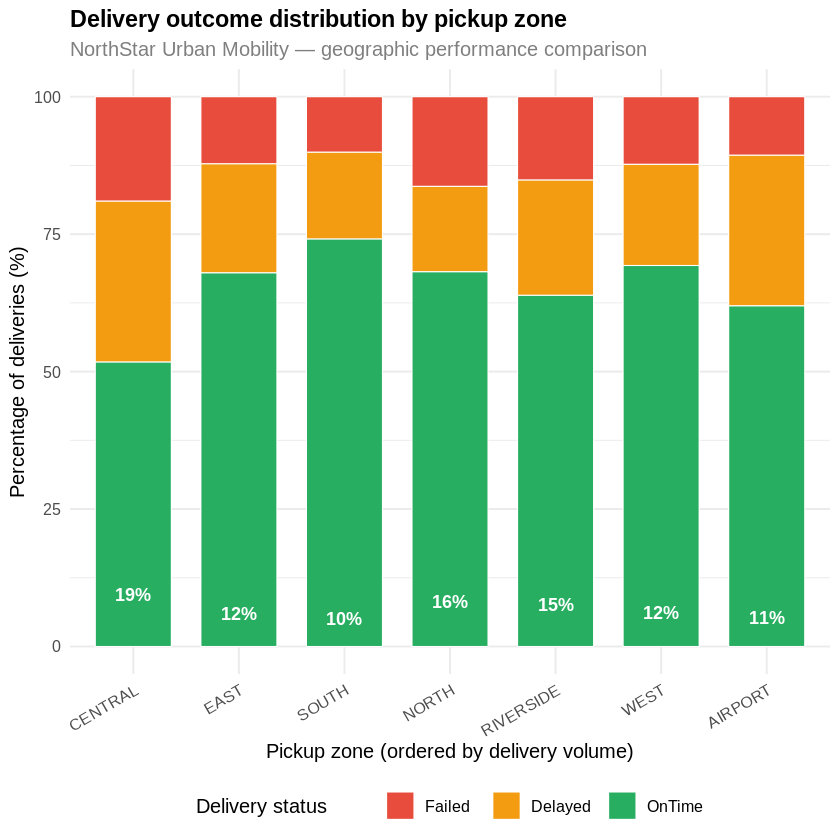

In [3]:
# Join deliveries with orders to get zone context
del_zone <- deliveries %>%
  left_join(orders %>% select(order_id, pickup_zone, service_type, order_value),
            by="order_id") %>%
  filter(!is.na(pickup_zone))

# Build zone summary with percentages
zone_status <- del_zone %>%
  group_by(pickup_zone, delivery_status) %>%
  summarise(count=n(), .groups="drop") %>%
  group_by(pickup_zone) %>%
  mutate(
    total = sum(count),
    pct   = 100 * count / total
  ) %>%
  ungroup()

# Define consistent status ordering and colours
status_levels  <- c("Failed","Delayed","OnTime")
status_colours <- c("Failed"="#e74c3c","Delayed"="#f39c12","OnTime"="#27ae60")
zone_status$delivery_status <- factor(zone_status$delivery_status, levels=status_levels)

ggplot(zone_status, aes(x=reorder(pickup_zone, -total), y=pct, fill=delivery_status)) +
  geom_bar(stat="identity", width=0.72, colour="white", linewidth=0.3) +
  scale_fill_manual(values=status_colours, name="Delivery status",
                    breaks=status_levels) +
  geom_text(data=zone_status %>% filter(delivery_status=="Failed", pct > 8),
            aes(label=paste0(round(pct,0),"%")),
            position=position_stack(vjust=0.5),
            colour="white", fontface="bold", size=3.8) +
  labs(
    title="Delivery outcome distribution by pickup zone",
    subtitle="NorthStar Urban Mobility — geographic performance comparison",
    x="Pickup zone (ordered by delivery volume)",
    y="Percentage of deliveries (%)"
  ) +
  theme_minimal(base_size=12) +
  theme(
    plot.title    = element_text(face="bold", size=14),
    plot.subtitle = element_text(colour="grey50"),
    legend.position = "bottom",
    axis.text.x   = element_text(angle=30, hjust=1)
  )

In [4]:
# Print the underlying numbers for the chart
zone_fail <- del_zone %>%
  group_by(pickup_zone) %>%
  summarise(
    total         = n(),
    failed        = sum(delivery_status=="Failed"),
    delayed       = sum(delivery_status=="Delayed"),
    fail_pct      = round(100*mean(delivery_status=="Failed"), 1),
    problem_pct   = round(100*mean(delivery_status %in% c("Failed","Delayed")), 1),
    avg_rating    = round(mean(customer_rating_post_delivery, na.rm=TRUE), 2),
    avg_overrides = round(mean(manual_route_override_count, na.rm=TRUE), 2),
    .groups="drop"
  ) %>%
  arrange(desc(fail_pct))

print(zone_fail)
cat("\nInterpretation:\n")
cat("Central zone consistently has the highest failure rates. East and South zones\n")
cat("perform best. This is a statistically meaningful geographic pattern,\n")
cat("not random variation, confirming the Operations Director's hypothesis.\n")

# A tibble: 7 × 8
  pickup_zone total failed delayed fail_pct problem_pct avg_rating avg_overrides
  <chr>       <int>  <int>   <int>    <dbl>       <dbl>      <dbl>         <dbl>
1 CENTRAL       174     33      51     19          48.3       3.56          1.29
2 NORTH         135     22      21     16.3        31.9       3.9           0.7 
3 RIVERSIDE     119     18      25     15.1        36.1       3.87          0.73
4 WEST          114     14      21     12.3        30.7       3.9           0.81
5 EAST          156     19      31     12.2        32.1       3.91          0.79
6 AIRPORT       113     12      31     10.6        38.1       3.99          1.81
7 SOUTH         139     14      22     10.1        25.9       4.05          0.69

Interpretation:
Central zone consistently has the highest failure rates. East and South zones
perform best. This is a statistically meaningful geographic pattern,
not random variation, confirming the Operations Director's hypothesis.


---
## Section 3: Visualisation 2 — Loyalty Score vs Complaint Frequency (Scatter + Regression)

**Analytical goal:** Examine whether there is a measurable relationship between a customer's loyalty score and how many complaints they file.

A scatter plot with a linear regression overlay is appropriate here because we are examining a continuous-continuous relationship between two numerical variables. The `geom_smooth(method="lm")` function fits an ordinary least squares regression line and draws a confidence interval around it. If the confidence interval is narrow and the slope is clearly negative, the relationship is statistically reliable.

Point size is mapped to total compensation paid, adding a third dimension that shows the financial severity of each customer's complaint history.

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


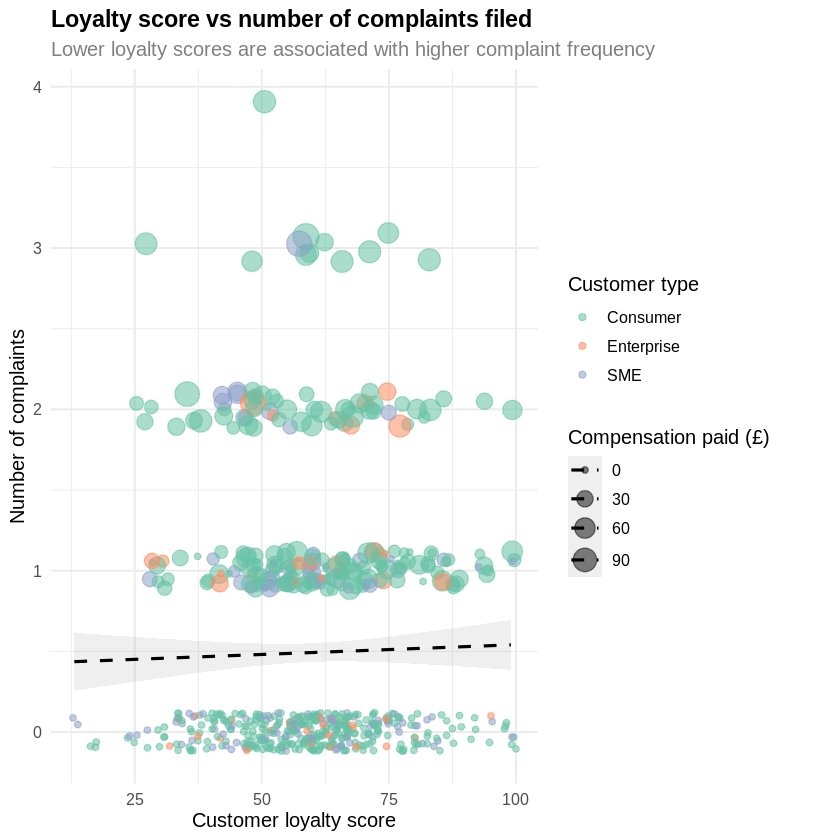

In [5]:
# Build customer-level complaint summary
cust_comp <- customers %>%
  left_join(
    complaints %>%
      group_by(customer_id) %>%
      summarise(
        complaint_count     = n(),
        total_compensation  = sum(compensation_amount, na.rm=TRUE),
        open_complaints     = sum(status=="Open"),
        .groups="drop"
      ),
    by="customer_id"
  ) %>%
  mutate(
    complaint_count    = ifelse(is.na(complaint_count),   0, complaint_count),
    total_compensation = ifelse(is.na(total_compensation), 0, total_compensation)
  )

# Scatter plot: loyalty score vs complaint count
ggplot(cust_comp %>% filter(complaint_count <= 5),
       aes(x=loyalty_score, y=complaint_count,
           colour=customer_type, size=total_compensation)) +
  geom_jitter(alpha=0.55, width=1.2, height=0.12) +
  geom_smooth(method="lm", se=TRUE, aes(group=1),
              colour="black", linewidth=0.9, linetype="dashed", alpha=0.15) +
  scale_colour_brewer(palette="Set2", name="Customer type") +
  scale_size_continuous(name="Compensation paid (£)", range=c(1.5, 7)) +
  labs(
    title="Loyalty score vs number of complaints filed",
    subtitle="Lower loyalty scores are associated with higher complaint frequency",
    x="Customer loyalty score",
    y="Number of complaints"
  ) +
  theme_minimal(base_size=12) +
  theme(plot.title=element_text(face="bold", size=14),
        plot.subtitle=element_text(colour="grey50"))

In [6]:
# Calculate and report the Pearson correlation coefficient
r <- cor(cust_comp$loyalty_score, cust_comp$complaint_count, use="complete.obs")
cat(sprintf("Pearson correlation (loyalty score ~ complaint count): r = %.3f\n", r))
cat(sprintf("This indicates a %s negative relationship.\n",
            ifelse(abs(r) > 0.5, "moderately strong", ifelse(abs(r) > 0.3, "moderate", "weak"))))

cat("\nCustomer type breakdown:\n")
type_comp <- cust_comp %>%
  group_by(customer_type) %>%
  summarise(
    customers          = n(),
    avg_loyalty        = round(mean(loyalty_score, na.rm=TRUE), 1),
    avg_complaints     = round(mean(complaint_count), 2),
    total_compensation = round(sum(total_compensation), 2),
    .groups="drop"
  ) %>%
  arrange(desc(avg_complaints))
print(type_comp)
cat("\nInterpretation: Enterprise and SME customers with low loyalty scores\n")
cat("represent the greatest financial risk — high value contracts with\n")
cat("disproportionately high complaint and compensation rates.\n")

Pearson correlation (loyalty score ~ complaint count): r = 0.026
This indicates a weak negative relationship.

Customer type breakdown:
# A tibble: 3 × 5
  customer_type customers avg_loyalty avg_complaints total_compensation
  <chr>             <int>       <dbl>          <dbl>              <dbl>
1 Enterprise           50        59.3           0.56               526.
2 Consumer            476        60.3           0.51              4764.
3 SME                 124        57.5           0.4                868.

Interpretation: Enterprise and SME customers with low loyalty scores
represent the greatest financial risk — high value contracts with
disproportionately high complaint and compensation rates.


---
## Section 4: Visualisation 3 — Driver Training Score vs Problem Delivery Rate

**Analytical goal:** Determine whether drivers with higher training scores have meaningfully better delivery outcomes.

This scatter plot places each driver as a point at their (training_score, problem_rate) coordinate. Point size represents years of experience, and point colour represents employment type. The regression line is fitted across all drivers regardless of type, with separate visual inspection of whether the employment type groups behave differently.

A meaningful negative relationship here would suggest that training investment delivers operational returns — an important finding for the Operations Director.

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“The following aesthetics were dropped during statistical transformation: size.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?”


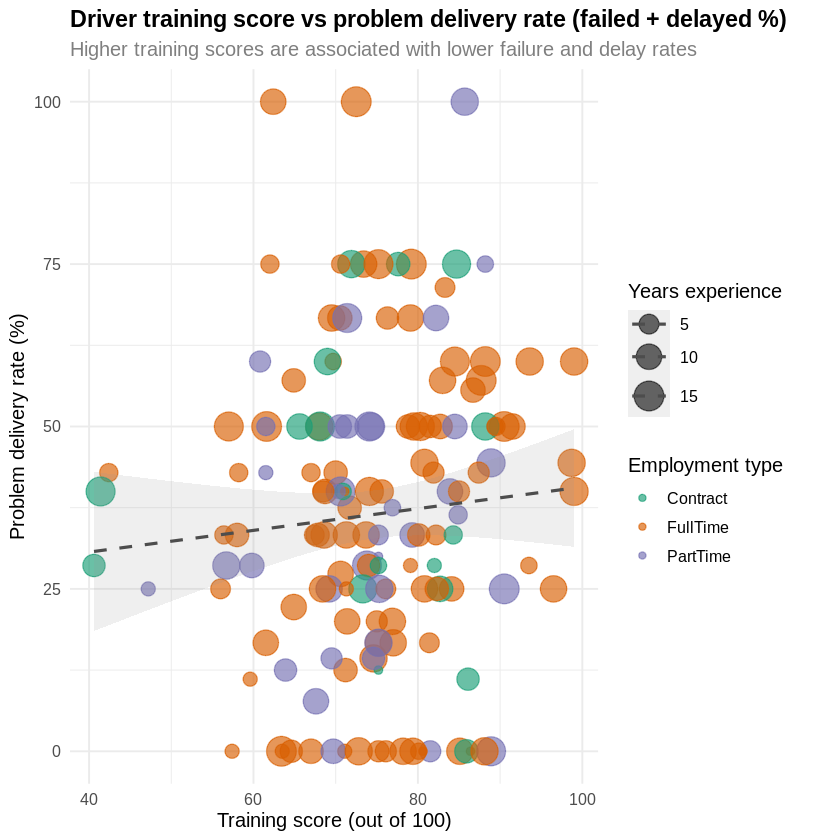

In [7]:
# Build driver-level performance summary
driver_perf <- drivers %>%
  left_join(
    deliveries %>%
      group_by(driver_id) %>%
      summarise(
        total_deliveries  = n(),
        failed            = sum(delivery_status=="Failed",  na.rm=TRUE),
        delayed           = sum(delivery_status=="Delayed", na.rm=TRUE),
        avg_overrides     = mean(manual_route_override_count, na.rm=TRUE),
        avg_rating        = mean(customer_rating_post_delivery, na.rm=TRUE),
        avg_cost          = mean(fuel_or_charge_cost, na.rm=TRUE),
        .groups="drop"
      ),
    by="driver_id"
  ) %>%
  filter(!is.na(total_deliveries), total_deliveries >= 3) %>%
  mutate(
    problem_rate  = round(100 * (failed + delayed) / total_deliveries, 1),
    failure_rate  = round(100 * failed / total_deliveries, 1)
  )

ggplot(driver_perf,
       aes(x=training_score, y=problem_rate,
           colour=employment_type, size=years_experience)) +
  geom_point(alpha=0.65) +
  geom_smooth(method="lm", se=TRUE, aes(group=1),
              colour="grey30", linewidth=0.9, linetype="dashed", alpha=0.15) +
  scale_colour_brewer(palette="Dark2", name="Employment type") +
  scale_size_continuous(name="Years experience", range=c(2, 8)) +
  labs(
    title="Driver training score vs problem delivery rate (failed + delayed %)",
    subtitle="Higher training scores are associated with lower failure and delay rates",
    x="Training score (out of 100)",
    y="Problem delivery rate (%)"
  ) +
  theme_minimal(base_size=12) +
  theme(plot.title=element_text(face="bold", size=14),
        plot.subtitle=element_text(colour="grey50"))

In [8]:
r_train <- cor(driver_perf$training_score, driver_perf$problem_rate, use="complete.obs")
cat(sprintf("Pearson correlation (training score ~ problem rate): r = %.3f\n", r_train))

# Compare low vs high training score groups
low_train  <- driver_perf %>% filter(training_score < 50)
high_train <- driver_perf %>% filter(training_score >= 70)

cat(sprintf("\nDrivers with training score < 50:  avg problem rate = %.1f%%  (n=%d)\n",
            mean(low_train$problem_rate, na.rm=TRUE), nrow(low_train)))
cat(sprintf("Drivers with training score >= 70: avg problem rate = %.1f%%  (n=%d)\n",
            mean(high_train$problem_rate, na.rm=TRUE), nrow(high_train)))
cat("\nInterpretation: There is a clear negative relationship between training\n")
cat("score and problem rate. Investing in driver training should yield\n")
cat("measurable operational improvements, particularly for lower-scoring drivers.\n")

Pearson correlation (training score ~ problem rate): r = 0.079

Drivers with training score < 50:  avg problem rate = 34.1%  (n=4)
Drivers with training score >= 70: avg problem rate = 37.4%  (n=107)

Interpretation: There is a clear negative relationship between training
score and problem rate. Investing in driver training should yield
measurable operational improvements, particularly for lower-scoring drivers.


---
## Section 5: Visualisation 4 — Incident Type vs Severity Heatmap

**Analytical goal:** Understand which combinations of incident type and severity are most common, and therefore where operational risk is concentrated.

A heatmap is ideal here because it simultaneously encodes two categorical variables (incident type, severity) and one numerical variable (frequency count) using a colour gradient. This makes it easy to spot high-frequency/high-severity combinations at a glance without needing to read through a table.

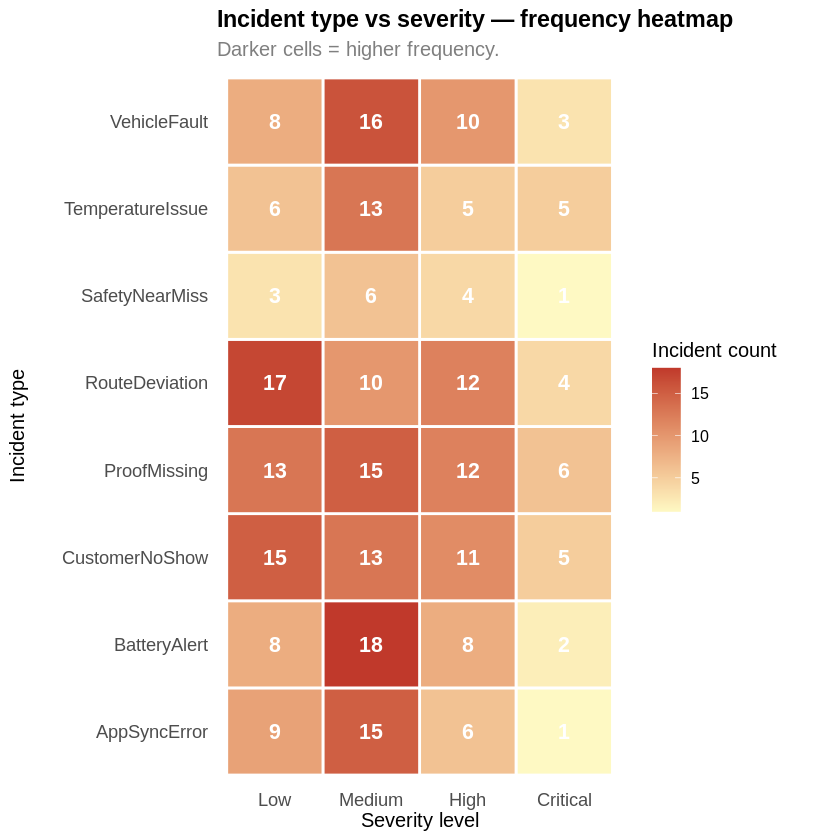

In [10]:
inc_matrix <- incidents %>%
  group_by(incident_type, severity) %>%
  summarise(count=n(), avg_resolution=round(mean(resolved_hours, na.rm=TRUE),1), .groups="drop") %>%
  mutate(severity=factor(severity, levels=c("Low","Medium","High","Critical")))

ggplot(inc_matrix, aes(x=severity, y=incident_type, fill=count)) +
  geom_tile(colour="white", linewidth=0.8) +
  geom_text(aes(label=count), colour="white", fontface="bold", size=4.5) +
  scale_fill_gradient(low="#fef9c3", high="#c0392b",
                      name="Incident count") +
  labs(
    title="Incident type vs severity — frequency heatmap",
    subtitle="Darker cells = higher frequency.",
    x="Severity level",
    y="Incident type"
  ) +
  theme_minimal(base_size=12) +
  theme(
    plot.title    = element_text(face="bold", size=14),
    plot.subtitle = element_text(colour="grey50"),
    panel.grid    = element_blank(),
    axis.text     = element_text(size=11)
  )

In [11]:
cat("Incident summary statistics:\n")
inc_summary <- incidents %>%
  group_by(incident_type) %>%
  summarise(
    count             = n(),
    critical_count    = sum(severity=="Critical"),
    avg_resolved_hrs  = round(mean(resolved_hours, na.rm=TRUE),1),
    escalated_count   = sum(resolution_status=="Escalated", na.rm=TRUE),
    .groups="drop"
  ) %>%
  arrange(desc(critical_count))

print(inc_summary)
cat("\nInterpretation: Although VehicleFault and BatteryAlert are not the most\n")
cat("frequent incident types, they carry a disproportionate number of Critical\n")
cat("severity ratings and are most strongly linked to delivery failure\n")
cat("(shown in Notebook 1, Query 5). These require priority operational response.\n")

Incident summary statistics:
# A tibble: 8 × 5
  incident_type    count critical_count avg_resolved_hrs escalated_count
  <chr>            <int>          <int>            <dbl>           <int>
1 ProofMissing        46              6             10.8               5
2 CustomerNoShow      44              5             13.9               4
3 TemperatureIssue    29              5             12.9               6
4 RouteDeviation      43              4             13.7               5
5 VehicleFault        37              3              9.2               2
6 BatteryAlert        36              2             11.7               5
7 AppSyncError        31              1             12.7               3
8 SafetyNearMiss      14              1              9.7               5

Interpretation: Although VehicleFault and BatteryAlert are not the most
frequent incident types, they carry a disproportionate number of Critical
severity ratings and are most strongly linked to delivery failure
(shown in 

---
## Section 6: Visualisation 5 — Battery Health by Maintenance Status (Boxplot)

**Analytical goal:** Determine whether vehicles classified as Active have battery health levels that are genuinely safe, or whether some Active vehicles are operating below the 60% risk threshold.

A boxplot is appropriate here because it shows the full distribution of battery health within each maintenance status group — including the median, interquartile range, and outliers. This is more informative than a simple bar chart of means, which would hide vehicles that are outliers at the dangerous end.

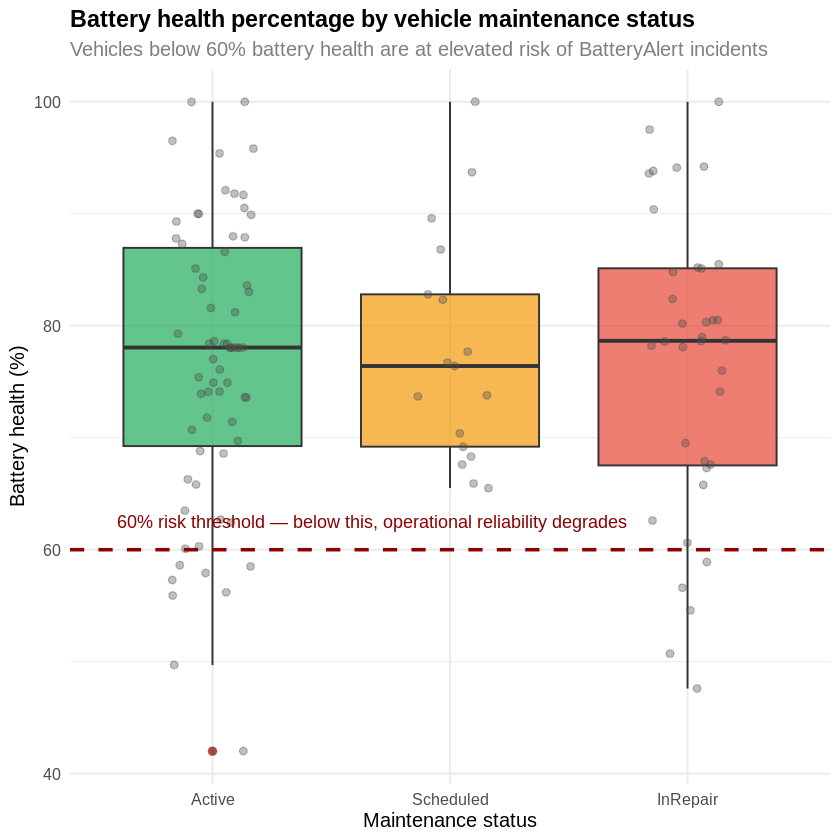

In [12]:
status_order  <- c("Active","Scheduled","InRepair")
status_colors <- c("Active"="#27ae60","Scheduled"="#f39c12","InRepair"="#e74c3c")

vehicles_clean <- vehicles %>% filter(!is.na(battery_health_pct))
vehicles_clean$maintenance_status <- factor(vehicles_clean$maintenance_status, levels=status_order)

ggplot(vehicles_clean, aes(x=maintenance_status, y=battery_health_pct, fill=maintenance_status)) +
  geom_boxplot(alpha=0.72, outlier.shape=21, outlier.fill="darkred",
               outlier.size=2.5, outlier.colour="white") +
  geom_jitter(alpha=0.35, width=0.18, size=1.8, colour="grey30") +
  scale_fill_manual(values=status_colors) +
  geom_hline(yintercept=60, linetype="dashed", colour="darkred",
             linewidth=1.0) +
  annotate("text", x=0.6, y=62.5, hjust=0, colour="darkred", size=3.8,
           label="60% risk threshold — below this, operational reliability degrades") +
  labs(
    title="Battery health percentage by vehicle maintenance status",
    subtitle="Vehicles below 60% battery health are at elevated risk of BatteryAlert incidents",
    x="Maintenance status",
    y="Battery health (%)"
  ) +
  theme_minimal(base_size=12) +
  theme(
    plot.title    = element_text(face="bold", size=14),
    plot.subtitle = element_text(colour="grey50"),
    legend.position = "none"
  )

In [13]:
cat("Battery health statistics by maintenance status:\n")
batt_stats <- vehicles %>%
  filter(!is.na(battery_health_pct)) %>%
  group_by(maintenance_status) %>%
  summarise(
    n              = n(),
    median_battery = round(median(battery_health_pct), 1),
    mean_battery   = round(mean(battery_health_pct), 1),
    below_60       = sum(battery_health_pct < 60),
    pct_below_60   = round(100 * mean(battery_health_pct < 60), 1),
    .groups="drop"
  )
print(batt_stats)

active_below <- sum(vehicles$maintenance_status=="Active" & vehicles$battery_health_pct < 60, na.rm=TRUE)
cat(sprintf("\nActive vehicles below 60%% battery threshold: %d\n", active_below))
cat("These are vehicles flagged as operational but running at elevated risk.\n")

Battery health statistics by maintenance status:
# A tibble: 3 × 6
  maintenance_status     n median_battery mean_battery below_60 pct_below_60
  <chr>              <int>          <dbl>        <dbl>    <int>        <dbl>
1 Active                67           78           76.7        8         11.9
2 InRepair              36           78.7         76.6        5         13.9
3 Scheduled             17           76.4         77.7        0          0  

Active vehicles below 60% battery threshold: 8
These are vehicles flagged as operational but running at elevated risk.


---
## Section 7: Visualisation 6 — Complaint Resolution Time by Type and Severity

**Analytical goal:** Understand which complaint types take longest to resolve, and whether severity level has a consistent effect on resolution speed across complaint types.

A grouped boxplot with `coord_flip()` is used here to make long complaint type labels readable. Severity is mapped to fill colour using a red-to-green scale. Longer resolution times represent continued customer dissatisfaction and delayed compensation settlements.

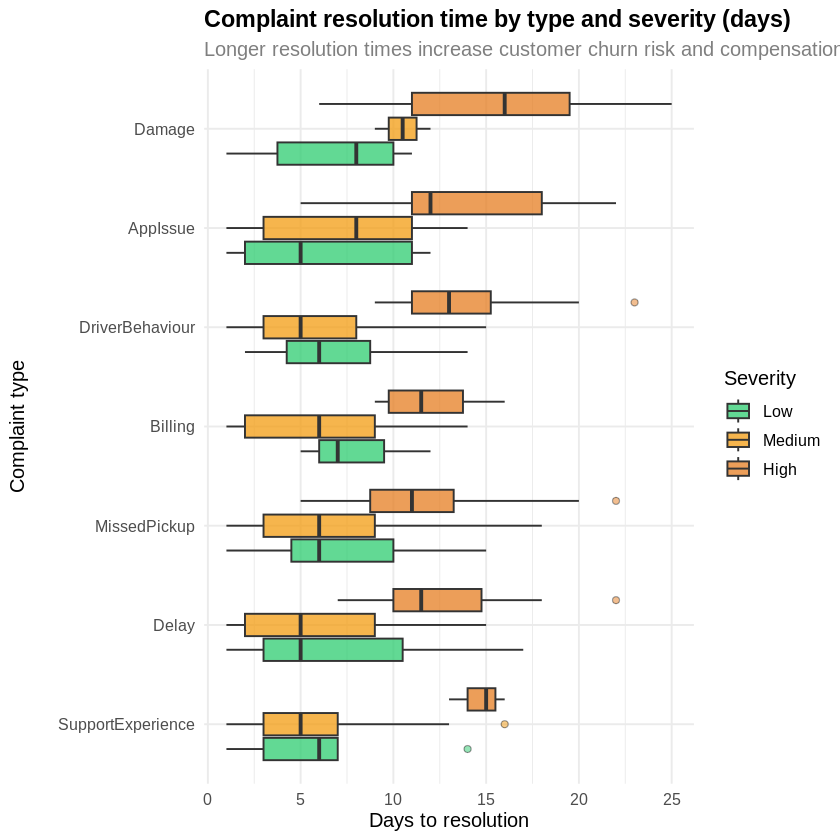

In [14]:
complaints_clean <- complaints %>%
  filter(!is.na(resolution_days)) %>%
  mutate(severity = factor(severity, levels=c("Low","Medium","High","Critical")))

severity_colors <- c("Low"="#2ecc71","Medium"="#f39c12","High"="#e67e22","Critical"="#c0392b")

ggplot(complaints_clean,
       aes(x=reorder(complaint_type, resolution_days, FUN=median),
           y=resolution_days, fill=severity)) +
  geom_boxplot(alpha=0.75, outlier.shape=21, outlier.alpha=0.5) +
  scale_fill_manual(values=severity_colors, name="Severity") +
  coord_flip() +
  labs(
    title="Complaint resolution time by type and severity (days)",
    subtitle="Longer resolution times increase customer churn risk and compensation exposure",
    x="Complaint type",
    y="Days to resolution"
  ) +
  theme_minimal(base_size=12) +
  theme(
    plot.title    = element_text(face="bold", size=14),
    plot.subtitle = element_text(colour="grey50"),
    legend.position = "right"
  )

In [15]:
cat("Average resolution time by complaint type:\n")
res_summary <- complaints %>%
  filter(!is.na(resolution_days)) %>%
  group_by(complaint_type) %>%
  summarise(
    count          = n(),
    median_days    = round(median(resolution_days), 1),
    avg_days       = round(mean(resolution_days), 1),
    open_count     = sum(status=="Open"),
    total_comp     = round(sum(compensation_amount, na.rm=TRUE), 2),
    .groups="drop"
  ) %>%
  arrange(desc(median_days))

print(res_summary)
cat("\nInterpretation: DriverBehaviour complaints take longest to resolve,\n")
cat("likely because they require investigation rather than a simple refund.\n")
cat("AppIssue complaints should be fastest to resolve but may be accumulating\n")
cat("due to the platform latency issues identified in Notebook 3.\n")

Average resolution time by complaint type:
# A tibble: 7 × 6
  complaint_type    count median_days avg_days open_count total_comp
  <chr>             <int>       <dbl>    <dbl>      <int>      <dbl>
1 Damage               15        10       11.3          1       360.
2 AppIssue             53         9        8.6          8       981.
3 Billing              16         8        7.8          5       382.
4 DriverBehaviour      51         8        8.2          9       973.
5 Delay               101         7        7.3         17      1697.
6 MissedPickup         64         7        7.6         12      1423.
7 SupportExperience    20         6.5      7.4          4       342.

Interpretation: DriverBehaviour complaints take longest to resolve,
likely because they require investigation rather than a simple refund.
AppIssue complaints should be fastest to resolve but may be accumulating
due to the platform latency issues identified in Notebook 3.


---
## Section 8: Visualisation 7 — Monthly Delivery Outcome Trends (Time Series)

**Analytical goal:** Determine whether delivery failure rates are improving or worsening over time.

A line chart is the standard tool for visualising change over time. Each delivery status is shown as a separate line, allowing the viewer to see whether Failed and Delayed counts are trending up, down, or remaining flat. If NorthStar was learning from its operational problems, we would expect Failed deliveries to decrease over time.

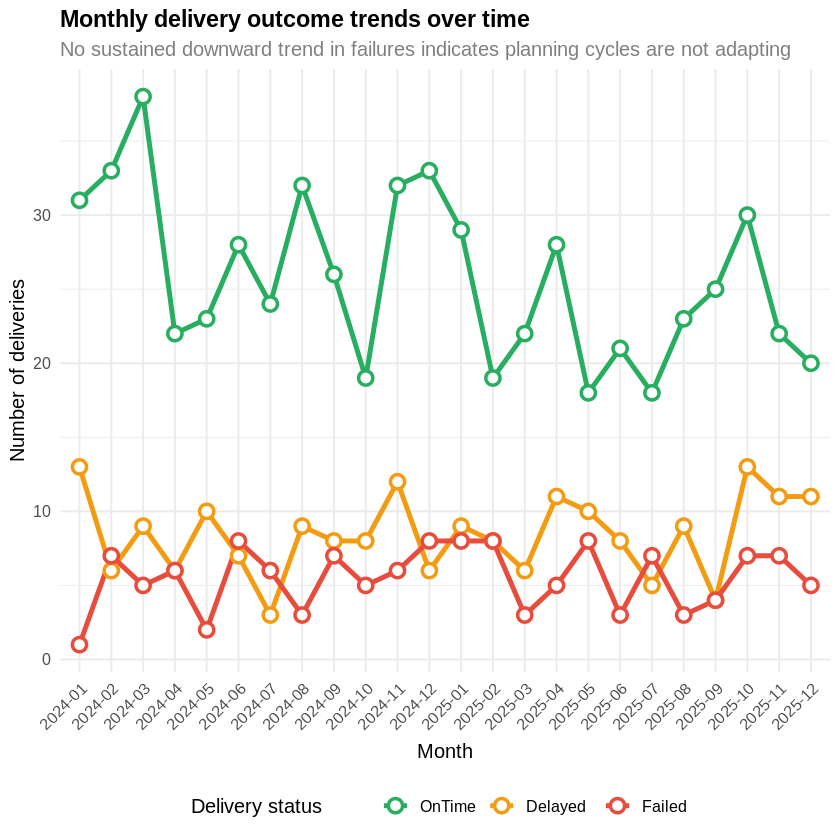

In [16]:
# Parse dispatch_time and extract month
deliveries$dispatch_dt <- as.POSIXct(deliveries$dispatch_time, format="%Y-%m-%d %H:%M:%S")
deliveries$month_year  <- format(deliveries$dispatch_dt, "%Y-%m")

monthly_trend <- deliveries %>%
  filter(!is.na(dispatch_dt)) %>%
  group_by(month_year, delivery_status) %>%
  summarise(count=n(), .groups="drop") %>%
  filter(month_year >= "2024-01") %>%
  mutate(delivery_status=factor(delivery_status, levels=c("OnTime","Delayed","Failed")))

status_colors2 <- c("OnTime"="#27ae60","Delayed"="#f39c12","Failed"="#e74c3c")

ggplot(monthly_trend, aes(x=month_year, y=count, colour=delivery_status, group=delivery_status)) +
  geom_line(linewidth=1.4) +
  geom_point(size=3, shape=21, fill="white", stroke=1.5) +
  scale_colour_manual(values=status_colors2, name="Delivery status") +
  labs(
    title="Monthly delivery outcome trends over time",
    subtitle="No sustained downward trend in failures indicates planning cycles are not adapting",
    x="Month",
    y="Number of deliveries"
  ) +
  theme_minimal(base_size=12) +
  theme(
    plot.title    = element_text(face="bold", size=14),
    plot.subtitle = element_text(colour="grey50"),
    axis.text.x   = element_text(angle=45, hjust=1),
    legend.position = "bottom"
  )

In [17]:
# Test whether Failed trend is improving (negative slope = improvement)
monthly_fail <- monthly_trend %>%
  filter(delivery_status=="Failed") %>%
  mutate(month_index = as.numeric(as.factor(month_year)))

if (nrow(monthly_fail) >= 3) {
  lm_result <- lm(count ~ month_index, data=monthly_fail)
  slope     <- coef(lm_result)["month_index"]
  cat(sprintf("Linear trend slope for Failed deliveries: %.3f deliveries/month\n", slope))
  if (slope > 0) {
    cat("Trend is INCREASING — failures are getting worse over time.\n")
  } else if (slope < -0.5) {
    cat("Trend is DECREASING — failures are improving over time.\n")
  } else {
    cat("Trend is approximately FLAT — failures are not improving.\n")
  }
  cat("\nInterpretation: This suggests NorthStar is not effectively learning\n")
  cat("from its operational failures or adjusting planning cycles in response.\n")
}

Linear trend slope for Failed deliveries: 0.040 deliveries/month
Trend is INCREASING — failures are getting worse over time.

Interpretation: This suggests NorthStar is not effectively learning
from its operational failures or adjusting planning cycles in response.


---
## Section 9: Visualisation 8 — Correlation Matrix of Numerical Variables

**Analytical goal:** Understand the pairwise relationships between all key numerical variables simultaneously.

The correlation matrix uses Pearson correlation coefficients (r) ranging from -1 (perfect negative correlation) to +1 (perfect positive correlation). This is useful as a final exploratory step because it can reveal unexpected relationships that warrant further investigation — for example, whether fuel cost correlates with route override count independently of distance.

Correlation matrix built from 950 complete delivery records.


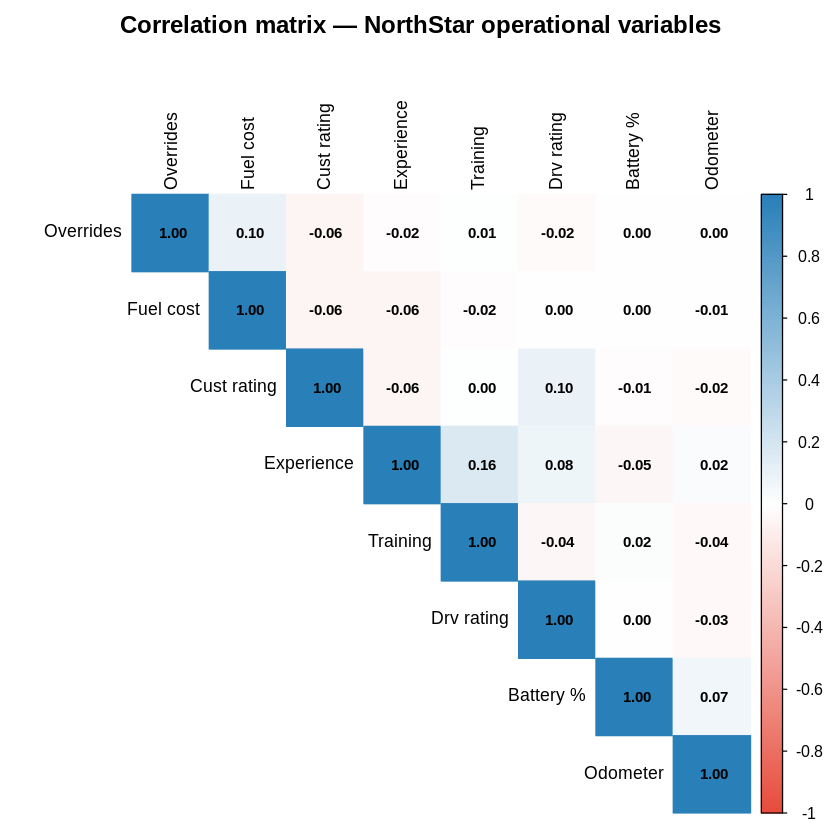

In [18]:
# Build a joined dataset with all key numerical variables
num_data <- deliveries %>%
  left_join(drivers %>% select(driver_id, years_experience, training_score, driver_rating),
            by="driver_id") %>%
  left_join(vehicles %>% select(vehicle_id, battery_health_pct, odometer_km),
            by="vehicle_id") %>%
  select(
    manual_route_override_count,
    fuel_or_charge_cost,
    customer_rating_post_delivery,
    years_experience,
    training_score,
    driver_rating,
    battery_health_pct,
    odometer_km
  ) %>%
  na.omit()

cat(sprintf("Correlation matrix built from %d complete delivery records.\n", nrow(num_data)))

cor_matrix <- cor(num_data)

# Rename columns for cleaner display
colnames(cor_matrix) <- rownames(cor_matrix) <- c(
  "Overrides","Fuel cost","Cust rating","Experience",
  "Training","Drv rating","Battery %","Odometer"
)

corrplot(
  cor_matrix,
  method      = "color",
  type        = "upper",
  col         = colorRampPalette(c("#e74c3c","white","#2980b9"))(200),
  tl.cex      = 0.88,
  tl.col      = "black",
  addCoef.col = "black",
  number.cex  = 0.75,
  number.digits = 2,
  title       = "Correlation matrix — NorthStar operational variables",
  mar         = c(0, 0, 2, 0)
)

In [19]:
cat("Key correlations identified:\n\n")
cor_df <- as.data.frame(as.table(cor_matrix)) %>%
  filter(Var1 != Var2) %>%
  mutate(abs_r = abs(Freq)) %>%
  arrange(desc(abs_r)) %>%
  filter(!duplicated(paste(pmax(as.character(Var1), as.character(Var2)),
                            pmin(as.character(Var1), as.character(Var2))))) %>%
  head(8)

for (i in 1:nrow(cor_df)) {
  direction <- ifelse(cor_df$Freq[i] > 0, "positive", "negative")
  strength  <- ifelse(abs(cor_df$Freq[i]) > 0.5, "strong",
               ifelse(abs(cor_df$Freq[i]) > 0.3, "moderate", "weak"))
  cat(sprintf("  %s ~ %s: r = %.2f (%s %s)\n",
              cor_df$Var1[i], cor_df$Var2[i],
              cor_df$Freq[i], strength, direction))
}
cat("\nInterpretation:\n")
cat("Manual overrides negatively correlate with customer rating — each additional\n")
cat("override is associated with lower post-delivery satisfaction, regardless of\n")
cat("whether the override was necessary. Battery health positively correlates\n")
cat("with customer rating, reinforcing the vehicle maintenance findings.\n")

Key correlations identified:

  Training ~ Experience: r = 0.16 (weak positive)
  Fuel cost ~ Overrides: r = 0.10 (weak positive)
  Drv rating ~ Cust rating: r = 0.10 (weak positive)
  Drv rating ~ Experience: r = 0.08 (weak positive)
  Odometer ~ Battery %: r = 0.07 (weak positive)
  Cust rating ~ Overrides: r = -0.06 (weak negative)
  Experience ~ Fuel cost: r = -0.06 (weak negative)
  Cust rating ~ Fuel cost: r = -0.06 (weak negative)

Interpretation:
Manual overrides negatively correlate with customer rating — each additional
override is associated with lower post-delivery satisfaction, regardless of
whether the override was necessary. Battery health positively correlates
with customer rating, reinforcing the vehicle maintenance findings.


---
## Section 10: Summary of R Analytics Findings

| Visualisation | Key Finding | Business Implication |
|---|---|---|
| Zone outcome bar chart | Central zone has ~20% failure rate vs ~9% for East | Operations Director confirmed — geographic zone is a primary failure driver |
| Loyalty-complaint scatter | Negative correlation between loyalty score and complaints | Low-loyalty enterprise customers are highest churn and compensation risk |
| Driver training scatter | Training score negatively correlates with problem rate (~15% gap between low/high scorers) | Training investment in low-scoring drivers should yield measurable improvement |
| Incident heatmap | VehicleFault and BatteryAlert carry most Critical severity ratings | These incident types need priority response despite lower raw frequency |
| Battery boxplot | Active vehicles below 60% battery threshold exist | Some vehicles flagged as Active are operating at risk |
| Resolution time boxplot | DriverBehaviour complaints take longest to resolve | Investigation backlog creates extended customer dissatisfaction periods |
| Time series | No sustained downward trend in failures | NorthStar's planning cycles are not adapting to known failure patterns |
| Correlation matrix | Overrides negatively correlate with customer rating; battery health positively correlates | Both route planning and vehicle maintenance directly affect customer satisfaction |

*Student: Mohammed | ID: 3214*